In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import time
import datetime
import lecilab_behavior_analysis.utils as utils


%load_ext autoreload
%autoreload 2

In [2]:
# see the available projects
tv_projects = utils.get_server_projects()
for i, p in enumerate(tv_projects):
    print(f"[{i}] {p}")

[0] auditory_escape_data
[1] cate_task_data
[2] COT_cannula_data
[3] COT_cannula_GAD2_data
[4] COT_unilateral_sound_data
[5] frequency_vs_location_data
[6] frequency_vs_locationPureTone_data
[7] retrocre_data
[8] sound_localization_paradigm_data
[9] Village_Towers_Task_data
[10] wireless_opto_data


In [3]:
# select a project
project = tv_projects[8]
print(f"Selected project: {project}")

Selected project: sound_localization_paradigm_data


In [4]:
# see the available animals
animals = utils.get_animals_in_project(project)
print(animals)

['LRV002', 'test1']


In [5]:
# select an animal and sync the data
mouse = 'test1'
local_path = Path(utils.get_outpath()) / Path(project) / Path("sessions")
# create the directory if it doesn't exist
local_path.mkdir(parents=True, exist_ok=True)
utils.rsync_cluster_data(
    project_name=project,
    file_path="sessions/{}".format(mouse),
    local_path=str(local_path),
    credentials=utils.get_idibaps_cluster_credentials(),
)

receiving incremental file list
test1/

sent 112 bytes  received 1,075 bytes  474.80 bytes/sec
total size is 2,435,119  speedup is 2,051.49


True

In [6]:
# see the files in the local session directory
files = list(Path(local_path / mouse).glob("*"))
for f in files:
    print(f.name)

test1.csv
test1_SoundLocalization_20260903_154922_IMU.parquet
test1_SoundLocalization_20260903_155211.csv
test1_SoundLocalization_20260903_155211.json
test1_SoundLocalization_20260903_155211_IMU.parquet
test1_SoundLocalization_20260903_155211_RAW.csv
test1_SoundLocalization_20260903_160032_IMU.parquet
test1_SoundLocalization_20260903_160658_IMU.parquet
test1_SoundLocalization_20260903_160833_IMU.parquet
test1_SoundLocalization_20260903_160956_IMU.parquet
test1_SoundLocalization_20260903_161540_IMU.parquet
test1_SoundLocalization_20260903_162759.csv
test1_SoundLocalization_20260903_162759.json
test1_SoundLocalization_20260903_162759_IMU.parquet
test1_SoundLocalization_20260903_162759_RAW.csv
test1_SoundLocalization_20260904_152525.csv
test1_SoundLocalization_20260904_152525.json
test1_SoundLocalization_20260904_152525_IMU.parquet
test1_SoundLocalization_20260904_152525_RAW.csv
test1_SoundLocalization_20260904_152753.csv
test1_SoundLocalization_20260904_152753.json
test1_SoundLocalizatio

In [7]:
# select a specific session
session_date = "20260908_102426"
# see the datasets for that session
valid_files = [f for f in files if session_date in f.name]
for f in valid_files:
    print(f.name)

test1_SoundLocalization_20260908_102426.csv
test1_SoundLocalization_20260908_102426.json
test1_SoundLocalization_20260908_102426_IMU.parquet
test1_SoundLocalization_20260908_102426_RAW.csv


In [8]:
# load them
sessiondf = pd.read_csv([f for f in valid_files if f.name.endswith(f"{session_date}.csv")][0], sep=";")
imu = pd.read_parquet([f for f in valid_files if f.name.endswith(f"{session_date}_IMU.parquet")][0])

In [9]:
sessiondf

,date,trial,subject,task,system_name,TRIAL_START,TRIAL_END,button_click,sound,ordered_list_of_events,sound_side,intensity,sound_duration,water,run_mode
0,2026-09-08 10:24:26,1,test1,SoundLocalization,village12,1.788856e+09,1.788856e+09,[1788855893.6784],[1788855893.6786],"['button_click', 'sound']",left,60,0.15,0,Manual
1,2026-09-08 10:24:26,2,test1,SoundLocalization,village12,1.788856e+09,1.788856e+09,[1788855896.0968],[1788855896.097],"['button_click', 'sound']",right,60,0.15,0,Manual
2,2026-09-08 10:24:26,3,test1,SoundLocalization,village12,1.788856e+09,1.788856e+09,[1788855929.7204],[1788855929.7207],"['button_click', 'sound']",left,50,0.15,0,Manual
3,2026-09-08 10:24:26,4,test1,SoundLocalization,village12,1.788856e+09,1.788856e+09,[1788855932.9496],[1788855932.9507],"['button_click', 'sound']",right,60,0.15,0,Manual
4,2026-09-08 10:24:26,5,test1,SoundLocalization,village12,1.788856e+09,1.788856e+09,[1788855982.2697],[1788855982.2701],"['button_click', 'sound']",left,70,0.15,0,Manual
5,2026-09-08 10:24:26,6,test1,SoundLocalization,village12,1.788856e+09,1.788856e+09,[1788855985.1079],[1788855985.1082],"['button_click', 'sound']",left,70,0.15,0,Manual
6,2026-09-08 10:24:26,7,test1,SoundLocalization,village12,1.788856e+09,1.788856e+09,[1788855987.5394],[1788855987.5398],"['button_click', 'sound']",left,70,0.15,0,Manual
7,2026-09-08 10:24:26,8,test1,SoundLocalization,village12,1.788856e+09,1.788856e+09,[1788855990.2718],[1788855990.272],"['button_click', 'sound']",left,50,0.15,0,Manual
8,2026-09-08 10:24:26,9,test1,SoundLocalization,village12,1.788856e+09,1.788856e+09,[1788855993.1384],[1788855993.1388],"['button_click', 'sound']",right,60,0.15,0,Manual
9,2026-09-08 10:24:26,10,test1,SoundLocalization,village12,1.788856e+09,1.788856e+09,[1788855996.0684],[1788855996.0685],"['button_click', 'sound']",right,60,0.15,0,Manual


In [24]:
# create a function that takes a trial and a window,
# and looks at the sync column that matches the trial
# and returns the set of values in the window surrounding the trial

def get_window_values(trial, samples_before, samples_after, imu_df):
    # check that there is only one value in sync matching this trial
    trial_sync_values = imu_df[imu_df["sync"] == trial]
    # if there are no sync values matching this trial, return an error
    if len(trial_sync_values) == 0:
        raise ValueError("No sync value found for trial", trial)
    if len(trial_sync_values) > 1:
        print("More than one sync value found for trial", trial)
        # take the first one as the sync index
    sync_idx = trial_sync_values.index[0]
    window_start = sync_idx - samples_before
    window_end = sync_idx + samples_after
    # if the number of values to return exceeds the dataframe bounds, give an error
    values = imu_df.loc[window_start:window_end]
    if len(values) != (samples_before + samples_after + 1):
        raise ValueError("The window exceeds the bounds of the dataframe")
    return values

In [33]:
get_window_values(trial=1, samples_before=100, samples_after=200, imu_df=imu)

ValueError: ('No sync value found for trial', 1)

In [27]:
# generate a dataframe that merges these two with the windowed values from the IMU dataframe for each trial and the corresponding trial information
dfs_to_concat = []
for _, row in sessiondf[:-1].iterrows(): # remove the last trial as it does not have a sound played
    try:
        windowed_values = get_window_values(trial=row["trial"], samples_before=100, samples_after=200, imu_df=imu).copy()
        # add a column with the window values
        windowed_values.loc[:, "window"] = range(len(windowed_values))
        # add a column with the trial number to the windowed values, and the date, the subject, the sound_side, the intensity, and the sound duration
        windowed_values.loc[:, "trial"] = row["trial"]
        windowed_values.loc[:, "date"] = row["date"]
        windowed_values.loc[:, "subject"] = row["subject"]
        windowed_values.loc[:, "sound_side"] = row["sound_side"]
        windowed_values.loc[:, "intensity"] = row["intensity"]
        windowed_values.loc[:, "sound_duration"] = row["sound_duration"]
        dfs_to_concat.append(windowed_values)
    except ValueError as e:
        print(e)
        continue
final_df = pd.concat(dfs_to_concat, axis=0).reset_index(drop=True)

('No sync value found for trial', 1)
('No sync value found for trial', 2)
('No sync value found for trial', 3)
('No sync value found for trial', 4)


In [28]:
final_df.columns

Index(['sample', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z',
       'roll', 'pitch', 'yaw', 'sync', 'window', 'trial', 'date', 'subject',
       'sound_side', 'intensity', 'sound_duration'],
      dtype='object')

In [34]:
def plot_imu_panel(column_to_plot, ax, dB=None):
    if dB is not None:
        df_to_plot = final_df[final_df["intensity"] == dB]
    else:
        df_to_plot = final_df
    color_palette = {"left": "blue", "right": "orange"}
    for trial in df_to_plot["trial"].unique():
        trial_data = df_to_plot[df_to_plot["trial"] == trial]
        ax.plot(trial_data["window"], trial_data[column_to_plot], color=color_palette[trial_data["sound_side"].iloc[0]], alpha=0.3)
    # plot the median
    mean_data = df_to_plot.groupby(["window", "sound_side"])[column_to_plot].median().reset_index()
    for sound_side in mean_data["sound_side"].unique():
        side_data = mean_data[mean_data["sound_side"] == sound_side]
        ax.plot(side_data["window"], side_data[column_to_plot], color=color_palette[sound_side], linewidth=2)
    # vertical line at window 100
    ax.axvline(x=100, color='r', linestyle='--')
    ax.set_title(f"{column_to_plot}", size=16)
    # despine
    sns.despine(ax=ax)
    return ax


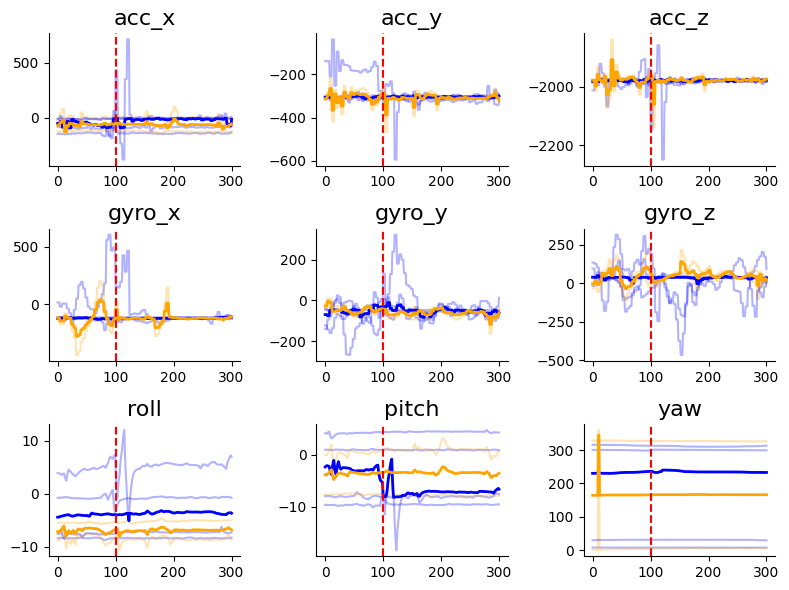

In [37]:
columns_to_plot = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'roll', 'pitch', 'yaw']
fig, axs = plt.subplots(figsize=(8, 6), nrows=3, ncols=3)
axs = axs.flatten()  # flatten the 3x3 array of axes for easy iteration
for ax, column_to_plot in zip(axs, columns_to_plot):
    plot_imu_panel(column_to_plot, ax, dB=None)
plt.tight_layout()
plt.show()

Another optimization would be to plot the delta in roll, pitch and yaw for instance, or the derivative of these values

In [31]:
# add derivative values to these 9 columns
for column in columns_to_plot:
    final_df[column + '_derivative'] = final_df[column].diff().rolling(window=10).median()

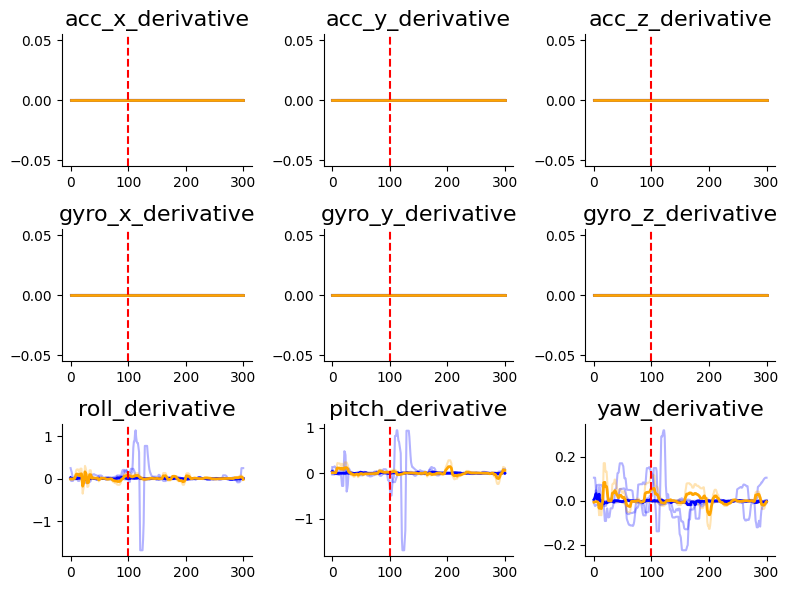

In [32]:
# remake the plot with the derivatives
fig, axs = plt.subplots(figsize=(8, 6), nrows=3, ncols=3)
axs = axs.flatten()  # flatten the 3x3 array of axes for easy iteration
for ax, column_to_plot in zip(axs, columns_to_plot):
    plot_imu_panel(column_to_plot + '_derivative', ax)
plt.tight_layout()
plt.show()

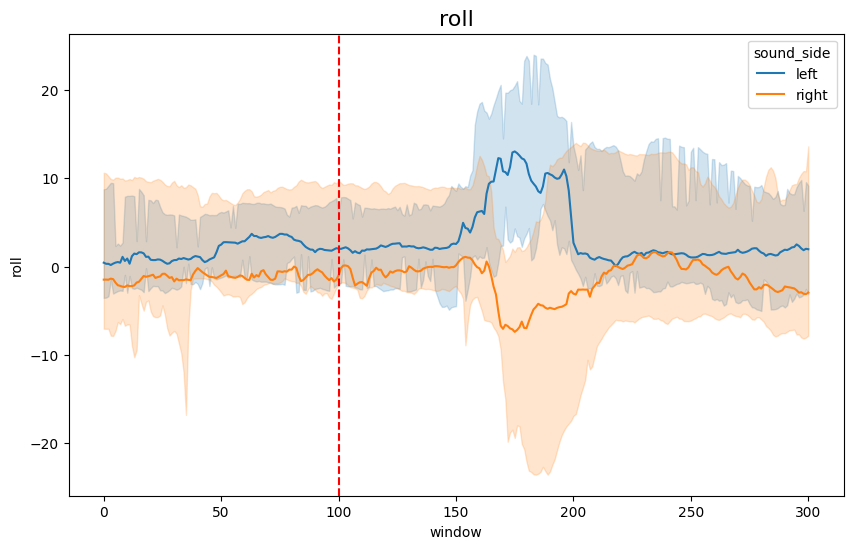

In [98]:
# plot with seaborn lines for each trial, colouring by sound_side, for a specific column
import seaborn as sns
import matplotlib.pyplot as plt

column_to_plot = "roll"  # replace with the column you want to plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=final_df, x="window", y=column_to_plot, hue="sound_side", estimator="median")
# vertical line at window 100
plt.axvline(x=100, color='r', linestyle='--')
plt.title(f"{column_to_plot}", size=16)
plt.show()